In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [31]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [32]:
# Feature Engineering

df = df.drop(
    columns=[
        'UDI',
        'Product ID',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ]
)

le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])

In [33]:
# Features & Target

X = df.drop('Machine failure', axis=1)

X.columns = [
    'Type',
    'Air_temperature',
    'Process_temperature',
    'Rotational_speed',
    'Torque',
    'Tool_wear'
]

y = df['Machine failure']

In [34]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [36]:
# Logistic Regression

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [37]:
# Decision Tree

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [38]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [39]:
X.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(">", "")
    for col in X.columns
]

In [40]:
# XGBoost

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [41]:
# Evaluation Function

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    return [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [42]:
# Compare Models

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.9880,0.907407,0.720588,0.803279
2,Random Forest,0.9815,0.878049,0.529412,0.660550
1,Decision Tree,0.9780,0.706897,0.602941,0.650794
0,Logistic Regression,0.8210,0.141089,0.838235,0.241525


In [43]:
# Classification Report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



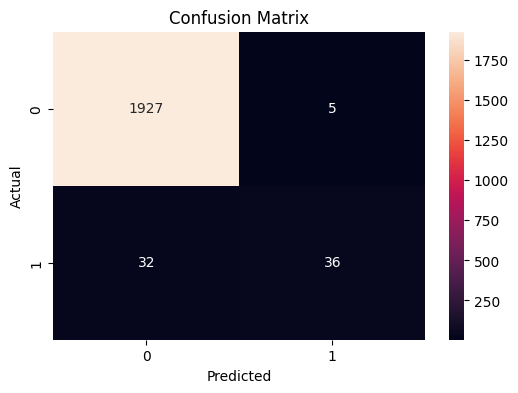

In [44]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [45]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Torque,0.328710
3,Rotational_speed,0.281911
5,Tool_wear,0.209064
1,Air_temperature,0.101160
2,Process_temperature,0.064740
0,Type,0.014416


In [46]:
# Save Best Model

joblib.dump(
    rf,
    "../models/model.pkl"
)

print("Model Saved")

Model Saved


In [47]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8210,0.141089,0.838235,0.241525
1,Decision Tree,0.9780,0.706897,0.602941,0.650794
2,Random Forest,0.9815,0.878049,0.529412,0.660550
3,XGBoost,0.9880,0.907407,0.720588,0.803279


In [48]:
# Best Model

import joblib

joblib.dump(
    xgb,
    "../models/model.pkl"
)

print("XGBoost Model Saved Successfully")

XGBoost Model Saved Successfully


               Feature  Importance
4               Torque    0.296056
3     Rotational_speed    0.223243
5            Tool_wear    0.171004
1      Air_temperature    0.153344
2  Process_temperature    0.092835
0                 Type    0.063518


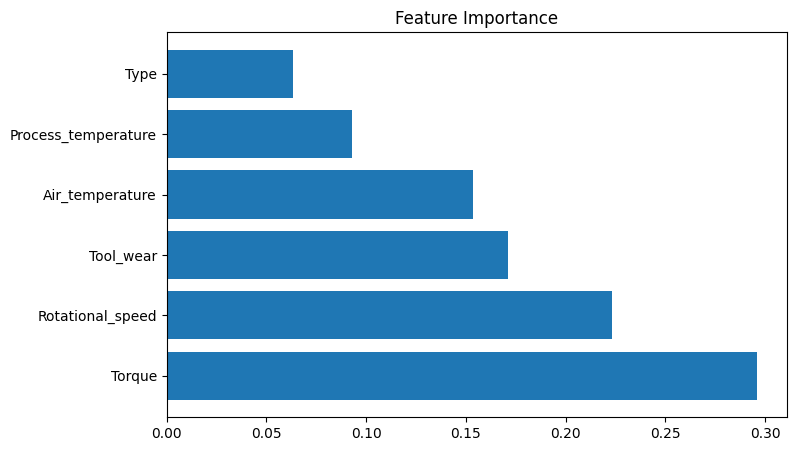

In [49]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.show()

In [2]:
import joblib

model = joblib.load("../models/model.pkl")

print(model.get_booster().feature_names)

['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']
